# LIBRARY

In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [5]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

# RF BIA-BIA_Fat

## Random forest (all features)

In [3]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'BIA-BIA_Fat']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['BIA-BIA_Fat'])


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 17)
y shape : (8396,)
Classes : [2.61172319e-02 1.41335225e-01 1.55976213e-01 ... 1.26172190e+02
 1.44216233e+02 1.53820000e+02]
Class counts : {0.0261172319401445: 1, 0.1413352248065393: 1, 0.1559762127008266: 1, 0.2119670898622612: 1, 0.2683961382866897: 1, 0.2845367889101329: 1, 0.386662: 1, 0.414636: 1, 0.4217681622630778: 1, 0.447879: 1, 0.4825217355239406: 1, 0.502266828062643: 1, 0.530487: 1, 0.6921464117729261: 1, 0.6943243806978128: 1, 0.6989912268334599: 1, 0.7464369589046154: 1, 0.7695964043547789: 1, 0.7937175712902675: 1, 0.914272: 1, 0.9278624147171168: 1, 0.9361240372254578: 1, 0.960596: 1, 1.03703: 1, 1.08337: 1, 1.10211: 1, 1.12023: 1, 1.12647: 1, 1.1374242649394244: 1, 1.2181847058501525: 1, 1.23591: 1, 1.24626: 1, 1.26681: 1, 1.26814: 1, 1.37804: 1, 1.394843438253826: 1, 1.40645: 1, 1.407073571447416: 1, 1.412902699076632: 1, 1.4147: 1, 1.43457: 1, 1.43891: 1, 1.4391140395920292: 1, 1.4610040771185189: 1, 1.4630604212994474: 1, 1.46925: 1, 1.48557469

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [5]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {0.1413352248065393: 1, 0.1559762127008266: 1, 0.2119670898622612: 1, 0.2683961382866897: 1, 0.2845367889101329: 1, 0.386662: 1, 0.414636: 1, 0.4217681622630778: 1, 0.447879: 1, 0.4825217355239406: 1, 0.502266828062643: 1, 0.530487: 1, 0.6921464117729261: 1, 0.6989912268334599: 1, 0.7464369589046154: 1, 0.914272: 1, 0.9278624147171168: 1, 1.08337: 1, 1.12023: 1, 1.12647: 1, 1.24626: 1, 1.26681: 1, 1.26814: 1, 1.37804: 1, 1.394843438253826: 1, 1.407073571447416: 1, 1.412902699076632: 1, 1.4147: 1, 1.43457: 1, 1.4610040771185189: 1, 1.4630604212994474: 1, 1.46925: 1, 1.4855746917833272: 1, 1.5850919235053809: 1, 1.60696907364178: 1, 1.6629486743368886: 1, 1.675231162552711: 1, 1.6916029807358584: 1, 1.7072039718993626: 1, 1.7178763418160568: 1, 1.729555539083382: 1, 1.7378501855288224: 1, 1.7398: 1, 1.7586866789156108: 1, 1.772913552110973: 1, 1.78031: 1, 1.78453: 1, 1.79586: 1, 1.79608: 1, 1.802109128893644: 1, 1.8404442816344064: 1, 1.84964: 1, 1.86497: 1, 1.90846: 1, 1.

In [6]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [8]:
def plot_roc_curve(X_test, y_test, best_model):    
# Predizioni probabilistiche
    y_score = best_model.predict_proba(X_test)

    # Classi
    classes = np.unique(y_test)

    # Binarizzazione delle etichette
    y_test_bin = label_binarize(y_test, classes=classes)

    # Plot
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Classe {class_name} (AUC = {roc_auc:.3f})'
        )

    # Linea casuale
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

In [9]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         [ 'friedman_mse', 'absolute_error', 'squared_error'],
}

In [10]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=KFold(                     
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='r2',  
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['friedman_mse', 'absolute_error', ...], 'max_depth': [5, 7, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that c

In [11]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")


── Best hyperparameters found ──────────────────────────
  n_estimators        : 500
  min_samples_split   : 5
  min_samples_leaf    : 2
  max_features        : log2
  max_depth           : 15
  criterion           : squared_error

  F1-macro (CV): 0.8384


In [12]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest params : {random_search.best_params_}")
print(f"RMSE  (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE   (test): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²    (test): {r2_score(y_test, y_pred):.4f}")


Best params : {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'squared_error'}
RMSE  (test): 6.1199
MAE   (test): 3.5471
R²    (test): 0.8606


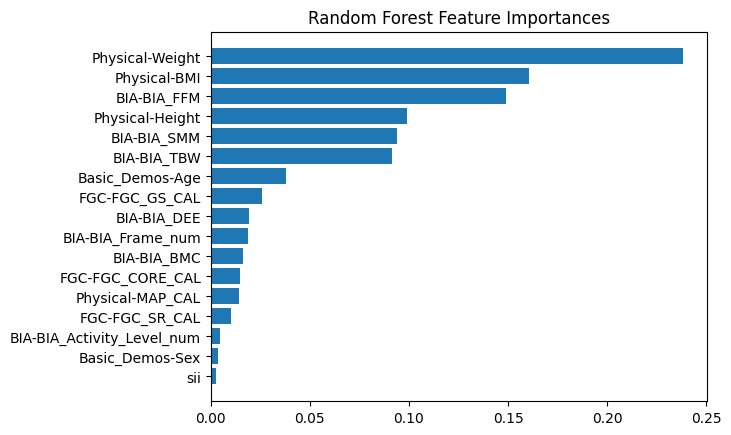

In [13]:
feature_imp(best_model, attributes)

## Random forest (reduced features)

In [14]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [15]:
column2drop = ['id', 'sii', 'Basic_Demos-Sex', 'Physical-MAP_CAL', 'FGC-FGC_CORE_CAL', 'FGC-FGC_SR_CAL', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_Frame_num']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'BIA-BIA_Fat']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['BIA-BIA_Fat'])


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 9)
y shape : (8396,)
Classes : [2.61172319e-02 1.41335225e-01 1.55976213e-01 ... 1.26172190e+02
 1.44216233e+02 1.53820000e+02]
Class counts : {0.0261172319401445: 1, 0.1413352248065393: 1, 0.1559762127008266: 1, 0.2119670898622612: 1, 0.2683961382866897: 1, 0.2845367889101329: 1, 0.386662: 1, 0.414636: 1, 0.4217681622630778: 1, 0.447879: 1, 0.4825217355239406: 1, 0.502266828062643: 1, 0.530487: 1, 0.6921464117729261: 1, 0.6943243806978128: 1, 0.6989912268334599: 1, 0.7464369589046154: 1, 0.7695964043547789: 1, 0.7937175712902675: 1, 0.914272: 1, 0.9278624147171168: 1, 0.9361240372254578: 1, 0.960596: 1, 1.03703: 1, 1.08337: 1, 1.10211: 1, 1.12023: 1, 1.12647: 1, 1.1374242649394244: 1, 1.2181847058501525: 1, 1.23591: 1, 1.24626: 1, 1.26681: 1, 1.26814: 1, 1.37804: 1, 1.394843438253826: 1, 1.40645: 1, 1.407073571447416: 1, 1.412902699076632: 1, 1.4147: 1, 1.43457: 1, 1.43891: 1, 1.4391140395920292: 1, 1.4610040771185189: 1, 1.4630604212994474: 1, 1.46925: 1, 1.485574691

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [17]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {0.1413352248065393: 1, 0.1559762127008266: 1, 0.2119670898622612: 1, 0.2683961382866897: 1, 0.2845367889101329: 1, 0.386662: 1, 0.414636: 1, 0.4217681622630778: 1, 0.447879: 1, 0.4825217355239406: 1, 0.502266828062643: 1, 0.530487: 1, 0.6921464117729261: 1, 0.6989912268334599: 1, 0.7464369589046154: 1, 0.914272: 1, 0.9278624147171168: 1, 1.08337: 1, 1.12023: 1, 1.12647: 1, 1.24626: 1, 1.26681: 1, 1.26814: 1, 1.37804: 1, 1.394843438253826: 1, 1.407073571447416: 1, 1.412902699076632: 1, 1.4147: 1, 1.43457: 1, 1.4610040771185189: 1, 1.4630604212994474: 1, 1.46925: 1, 1.4855746917833272: 1, 1.5850919235053809: 1, 1.60696907364178: 1, 1.6629486743368886: 1, 1.675231162552711: 1, 1.6916029807358584: 1, 1.7072039718993626: 1, 1.7178763418160568: 1, 1.729555539083382: 1, 1.7378501855288224: 1, 1.7398: 1, 1.7586866789156108: 1, 1.772913552110973: 1, 1.78031: 1, 1.78453: 1, 1.79586: 1, 1.79608: 1, 1.802109128893644: 1, 1.8404442816344064: 1, 1.84964: 1, 1.86497: 1, 1.90846: 1, 1.

In [18]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [20]:
def plot_roc_curve(X_test, y_test, best_model):    
# Predizioni probabilistiche
    y_score = best_model.predict_proba(X_test)

    # Classi
    classes = np.unique(y_test)

    # Binarizzazione delle etichette
    y_test_bin = label_binarize(y_test, classes=classes)

    # Plot
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Classe {class_name} (AUC = {roc_auc:.3f})'
        )

    # Linea casuale
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

In [21]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         [ 'friedman_mse', 'absolute_error', 'squared_error'],
}

In [22]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=KFold(                     
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='r2',  
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['friedman_mse', 'absolute_error', ...], 'max_depth': [5, 7, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that c

In [23]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")


── Best hyperparameters found ──────────────────────────
  n_estimators        : 500
  min_samples_split   : 5
  min_samples_leaf    : 2
  max_features        : log2
  max_depth           : 15
  criterion           : squared_error

  F1-macro (CV): 0.8945


In [24]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest params : {random_search.best_params_}")
print(f"RMSE  (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE   (test): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²    (test): {r2_score(y_test, y_pred):.4f}")


Best params : {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'squared_error'}
RMSE  (test): 4.7648
MAE   (test): 2.6485
R²    (test): 0.9155


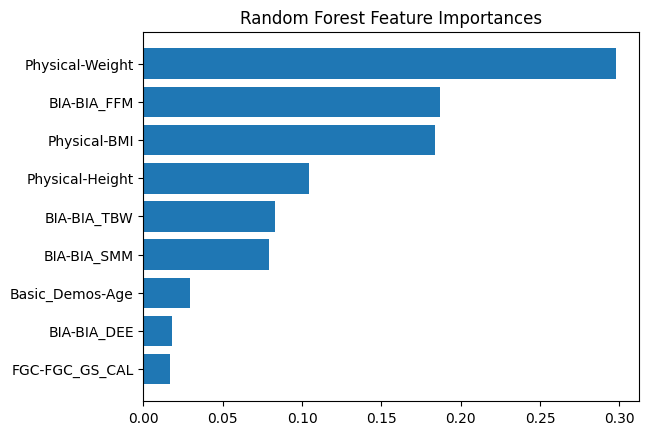

In [25]:
feature_imp(best_model, attributes)

In [26]:
attributes

['Basic_Demos-Age',
 'Physical-BMI',
 'Physical-Height',
 'Physical-Weight',
 'FGC-FGC_GS_CAL',
 'BIA-BIA_DEE',
 'BIA-BIA_FFM',
 'BIA-BIA_SMM',
 'BIA-BIA_TBW']

### GRAPHIC

In [27]:
import seaborn as sns 

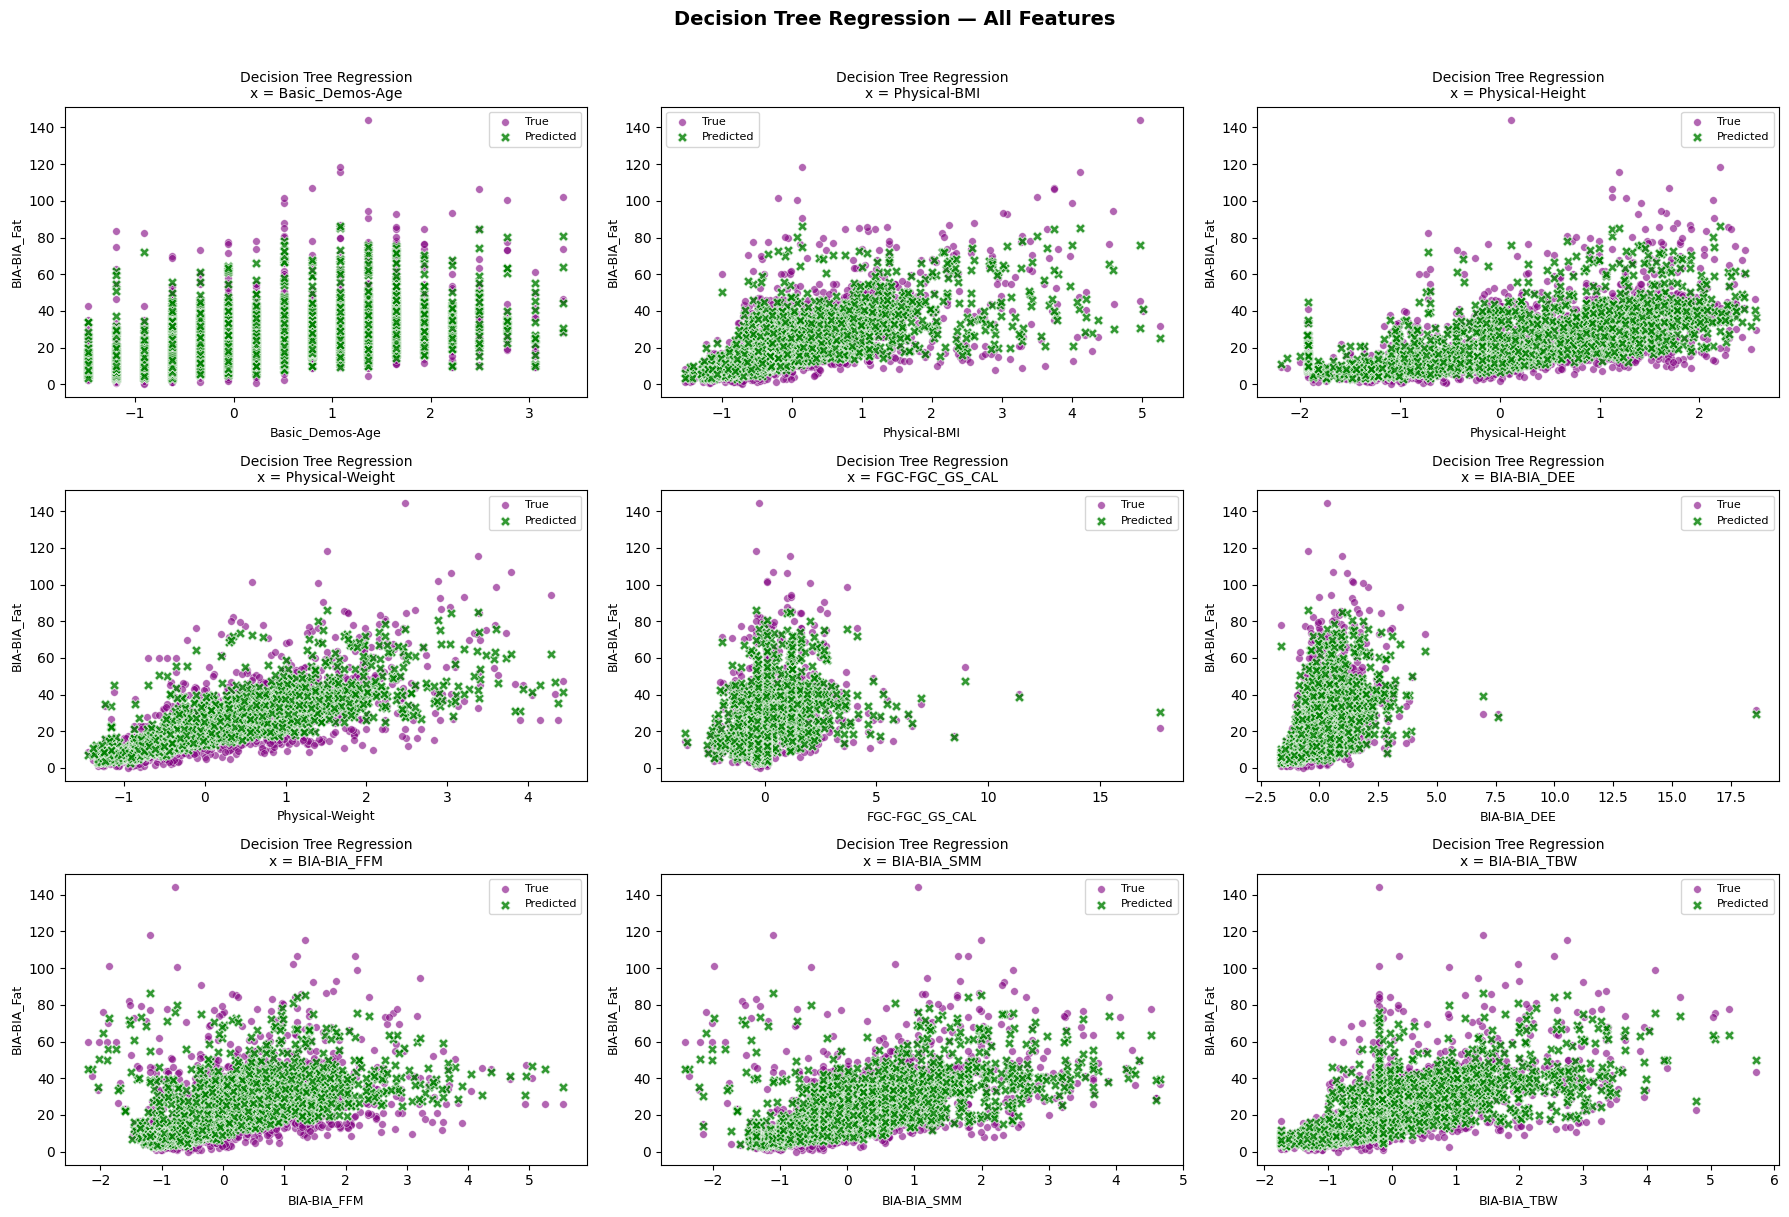

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_all_feature_predictions(X_test, y_test, model, feature_names=None,
                                  title='Model Predictions', color_true='purple',
                                  color_pred='green'):
    """
    Plots predicted vs true values for every feature in X_test as the x-axis.

    Parameters
    ----------
    X_test        : test features array  shape (n_samples, n_features)
    y_test        : true target values   shape (n_samples,)
    model         : trained model with .predict() method
    feature_names : list of feature names — if None uses ['feature_0', ...]
    title         : base title for each subplot
    color_true    : color for true values
    color_pred    : color for predicted values
    """

    n_features = X_test.shape[1]
    y_pred     = model.predict(X_test)

    # ── Feature names ─────────────────────────────────────────────────────────
    if feature_names is None:
        feature_names = [f'feature_{i}' for i in range(n_features)]

    # ── Grid layout — auto calculate rows and cols ────────────────────────────
    n_cols = 3                                    # 3 plots per row
    n_rows = math.ceil(n_features / n_cols)       # enough rows to fit all

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 6, n_rows * 4))
    axes = axes.flatten()     # convert 2D grid to 1D list for easy iteration

    # ── One plot per feature ──────────────────────────────────────────────────
    for i in range(n_features):
        ax = axes[i]

        plot_df = pd.DataFrame({
            'feature':   X_test[:, i],    # ← X_test[:, i] changes each loop
            'true':      y_test,
            'predicted': y_pred,
        })

        # true values
        sns.scatterplot(data=plot_df, x='feature', y='true',
                        label='True', color=color_true,
                        alpha=0.6, s=30, ax=ax)

        # predicted values
        sns.scatterplot(data=plot_df, x='feature', y='predicted',
                        label='Predicted', marker='X', color=color_pred,
                        alpha=0.8, s=50, ax=ax)

        ax.set_title(f'{title}\nx = {feature_names[i]}', fontsize=10)
        ax.set_xlabel(feature_names[i], fontsize=9)
        ax.set_ylabel('BIA-BIA_Fat', fontsize=9)
        ax.legend(fontsize=8)

    # ── Hide empty subplots if n_features is not divisible by n_cols ─────────
    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'{title} — All Features', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
feature_names = [
'Basic_Demos-Age',
'Physical-BMI',
'Physical-Height',
'Physical-Weight',
'FGC-FGC_GS_CAL',
'BIA-BIA_DEE',
'BIA-BIA_FFM',
'BIA-BIA_SMM',
'BIA-BIA_TBW'
]   # ← replace with your actual column names, or leave None for auto naming

plot_all_feature_predictions(
    X_test        = X_test,
    y_test        = y_test,
    model         = best_model,
    feature_names = feature_names,
    title         = 'Decision Tree Regression',
    color_true    = 'purple',
    color_pred    = 'green',
)

# RF BIA-BIA_SMM

## Random forest (all features)

In [6]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [7]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'BIA-BIA_SMM']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['BIA-BIA_SMM'])


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 17)
y shape : (8396,)
Classes : [ 0.59056648  1.43006828  1.46180752 ... 84.3910334  89.3602
 89.4884    ]
Class counts : {0.5905664760120359: 1, 1.4300682819188886: 1, 1.461807515682601: 1, 1.6182619813301926: 1, 2.2110761126819405: 1, 2.586985953459859: 1, 2.7211293841876447: 1, 3.925588590113364: 1, 4.088467595735214: 1, 4.16082033841721: 1, 4.65573: 3, 4.690058053864007: 1, 4.906413093618454: 1, 5.113253001545111: 1, 5.138024625640213: 1, 5.147592982268819: 1, 6.082856940867913: 1, 6.174754683600405: 1, 6.216926349805693: 1, 6.249795904716159: 1, 6.347003264672487: 1, 6.501384330487781: 1, 6.704515114834571: 1, 7.625264686888286: 1, 7.685130628110869: 1, 8.416315250705217: 1, 8.42916070044232: 1, 8.7720390428405: 1, 8.800647970703755: 1, 8.836692962060372: 1, 9.055090484787955: 1, 9.239066804392795: 1, 9.322709022754648: 1, 9.43086490081118: 1, 9.609664922307282: 1, 9.751226986202926: 1, 10.474591353562298: 1, 10.571487970703757: 7, 10.769392224407746: 1, 11.027768

In [53]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [54]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {0.5905664760120359: 1, 1.461807515682601: 1, 1.6182619813301926: 1, 2.586985953459859: 1, 2.7211293841876447: 1, 4.16082033841721: 1, 4.65573: 1, 4.690058053864007: 1, 4.906413093618454: 1, 5.113253001545111: 1, 5.138024625640213: 1, 6.082856940867913: 1, 6.174754683600405: 1, 6.347003264672487: 1, 6.704515114834571: 1, 7.625264686888286: 1, 7.685130628110869: 1, 8.416315250705217: 1, 8.7720390428405: 1, 8.836692962060372: 1, 9.055090484787955: 1, 9.322709022754648: 1, 9.43086490081118: 1, 9.751226986202926: 1, 10.474591353562298: 1, 10.571487970703757: 4, 10.769392224407746: 1, 11.167109513990937: 1, 11.188213998931396: 1, 11.355350757544135: 1, 11.3825: 1, 11.586247784619452: 1, 11.634742368775589: 1, 11.7991: 1, 11.854731293182502: 1, 11.953940159144398: 1, 11.98624777219456: 1, 12.11864544136491: 1, 12.126443579895684: 4, 12.1372: 1, 12.163068962858306: 1, 12.171664318549556: 1, 12.17767628276134: 1, 12.18005740889654: 1, 12.22250300324712: 1, 12.372751522780815: 1,

In [55]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [57]:
def plot_roc_curve(X_test, y_test, best_model):    
# Predizioni probabilistiche
    y_score = best_model.predict_proba(X_test)

    # Classi
    classes = np.unique(y_test)

    # Binarizzazione delle etichette
    y_test_bin = label_binarize(y_test, classes=classes)

    # Plot
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Classe {class_name} (AUC = {roc_auc:.3f})'
        )

    # Linea casuale
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

In [58]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         [ 'friedman_mse', 'absolute_error', 'squared_error'],
}

In [59]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=KFold(                     
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='r2',  
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['friedman_mse', 'absolute_error', ...], 'max_depth': [5, 7, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that c

In [60]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")


── Best hyperparameters found ──────────────────────────
  n_estimators        : 500
  min_samples_split   : 5
  min_samples_leaf    : 2
  max_features        : log2
  max_depth           : 15
  criterion           : squared_error

  F1-macro (CV): 0.7448


In [61]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest params : {random_search.best_params_}")
print(f"RMSE  (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE   (test): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²    (test): {r2_score(y_test, y_pred):.4f}")


Best params : {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'squared_error'}
RMSE  (test): 6.0218
MAE   (test): 4.1014
R²    (test): 0.7449


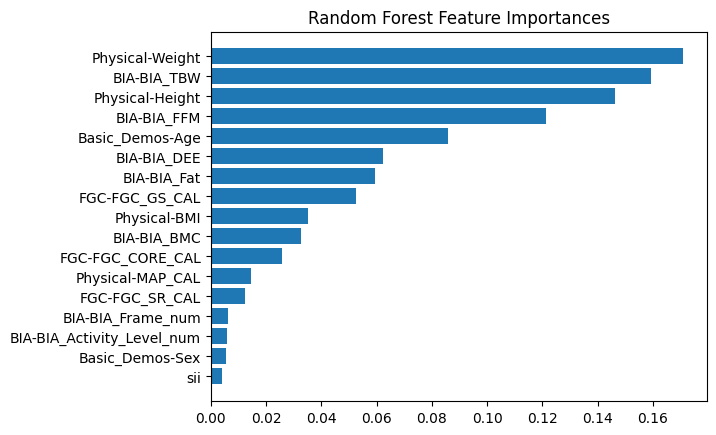

In [62]:
feature_imp(best_model, attributes)

## Random forest (reduced features)

In [16]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [17]:
column2drop = ['id', 'sii', 'Basic_Demos-Sex', 'Physical-MAP_CAL', 'FGC-FGC_CORE_CAL', 'FGC-FGC_SR_CAL', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_Frame_num']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'BIA-BIA_SMM']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['BIA-BIA_SMM'])


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 9)
y shape : (8396,)
Classes : [ 0.59056648  1.43006828  1.46180752 ... 84.3910334  89.3602
 89.4884    ]
Class counts : {0.5905664760120359: 1, 1.4300682819188886: 1, 1.461807515682601: 1, 1.6182619813301926: 1, 2.2110761126819405: 1, 2.586985953459859: 1, 2.7211293841876447: 1, 3.925588590113364: 1, 4.088467595735214: 1, 4.16082033841721: 1, 4.65573: 3, 4.690058053864007: 1, 4.906413093618454: 1, 5.113253001545111: 1, 5.138024625640213: 1, 5.147592982268819: 1, 6.082856940867913: 1, 6.174754683600405: 1, 6.216926349805693: 1, 6.249795904716159: 1, 6.347003264672487: 1, 6.501384330487781: 1, 6.704515114834571: 1, 7.625264686888286: 1, 7.685130628110869: 1, 8.416315250705217: 1, 8.42916070044232: 1, 8.7720390428405: 1, 8.800647970703755: 1, 8.836692962060372: 1, 9.055090484787955: 1, 9.239066804392795: 1, 9.322709022754648: 1, 9.43086490081118: 1, 9.609664922307282: 1, 9.751226986202926: 1, 10.474591353562298: 1, 10.571487970703757: 7, 10.769392224407746: 1, 11.0277687

In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [19]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {0.5905664760120359: 1, 1.461807515682601: 1, 1.6182619813301926: 1, 2.586985953459859: 1, 2.7211293841876447: 1, 4.16082033841721: 1, 4.65573: 1, 4.690058053864007: 1, 4.906413093618454: 1, 5.113253001545111: 1, 5.138024625640213: 1, 6.082856940867913: 1, 6.174754683600405: 1, 6.347003264672487: 1, 6.704515114834571: 1, 7.625264686888286: 1, 7.685130628110869: 1, 8.416315250705217: 1, 8.7720390428405: 1, 8.836692962060372: 1, 9.055090484787955: 1, 9.322709022754648: 1, 9.43086490081118: 1, 9.751226986202926: 1, 10.474591353562298: 1, 10.571487970703757: 4, 10.769392224407746: 1, 11.167109513990937: 1, 11.188213998931396: 1, 11.355350757544135: 1, 11.3825: 1, 11.586247784619452: 1, 11.634742368775589: 1, 11.7991: 1, 11.854731293182502: 1, 11.953940159144398: 1, 11.98624777219456: 1, 12.11864544136491: 1, 12.126443579895684: 4, 12.1372: 1, 12.163068962858306: 1, 12.171664318549556: 1, 12.17767628276134: 1, 12.18005740889654: 1, 12.22250300324712: 1, 12.372751522780815: 1,

In [20]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [22]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         [ 'friedman_mse', 'absolute_error', 'squared_error'],
}

In [23]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=KFold(                     
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='r2',  
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['friedman_mse', 'absolute_error', ...], 'max_depth': [5, 7, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that c

In [24]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")


── Best hyperparameters found ──────────────────────────
  n_estimators        : 500
  min_samples_split   : 5
  min_samples_leaf    : 2
  max_features        : log2
  max_depth           : 15
  criterion           : squared_error

  F1-macro (CV): 0.7398


In [25]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest params : {random_search.best_params_}")
print(f"RMSE  (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE   (test): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²    (test): {r2_score(y_test, y_pred):.4f}")


Best params : {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'squared_error'}
RMSE  (test): 6.1024
MAE   (test): 4.1698
R²    (test): 0.7380


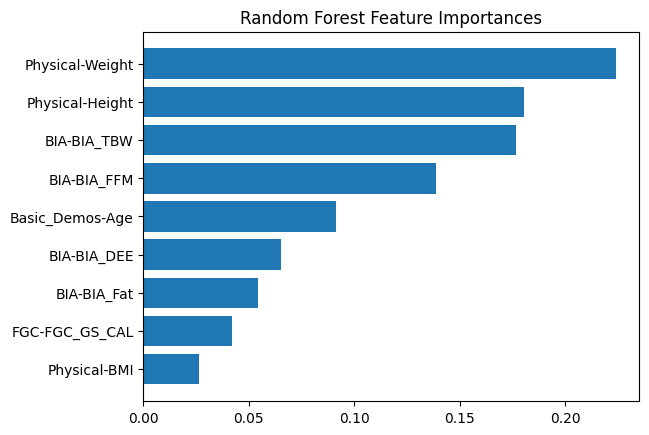

In [26]:
feature_imp(best_model, attributes)

## GRAPHIC 

In [30]:
attributes

['Basic_Demos-Age',
 'Physical-BMI',
 'Physical-Height',
 'Physical-Weight',
 'FGC-FGC_GS_CAL',
 'BIA-BIA_DEE',
 'BIA-BIA_FFM',
 'BIA-BIA_Fat',
 'BIA-BIA_TBW']

In [31]:
import seaborn as sns 

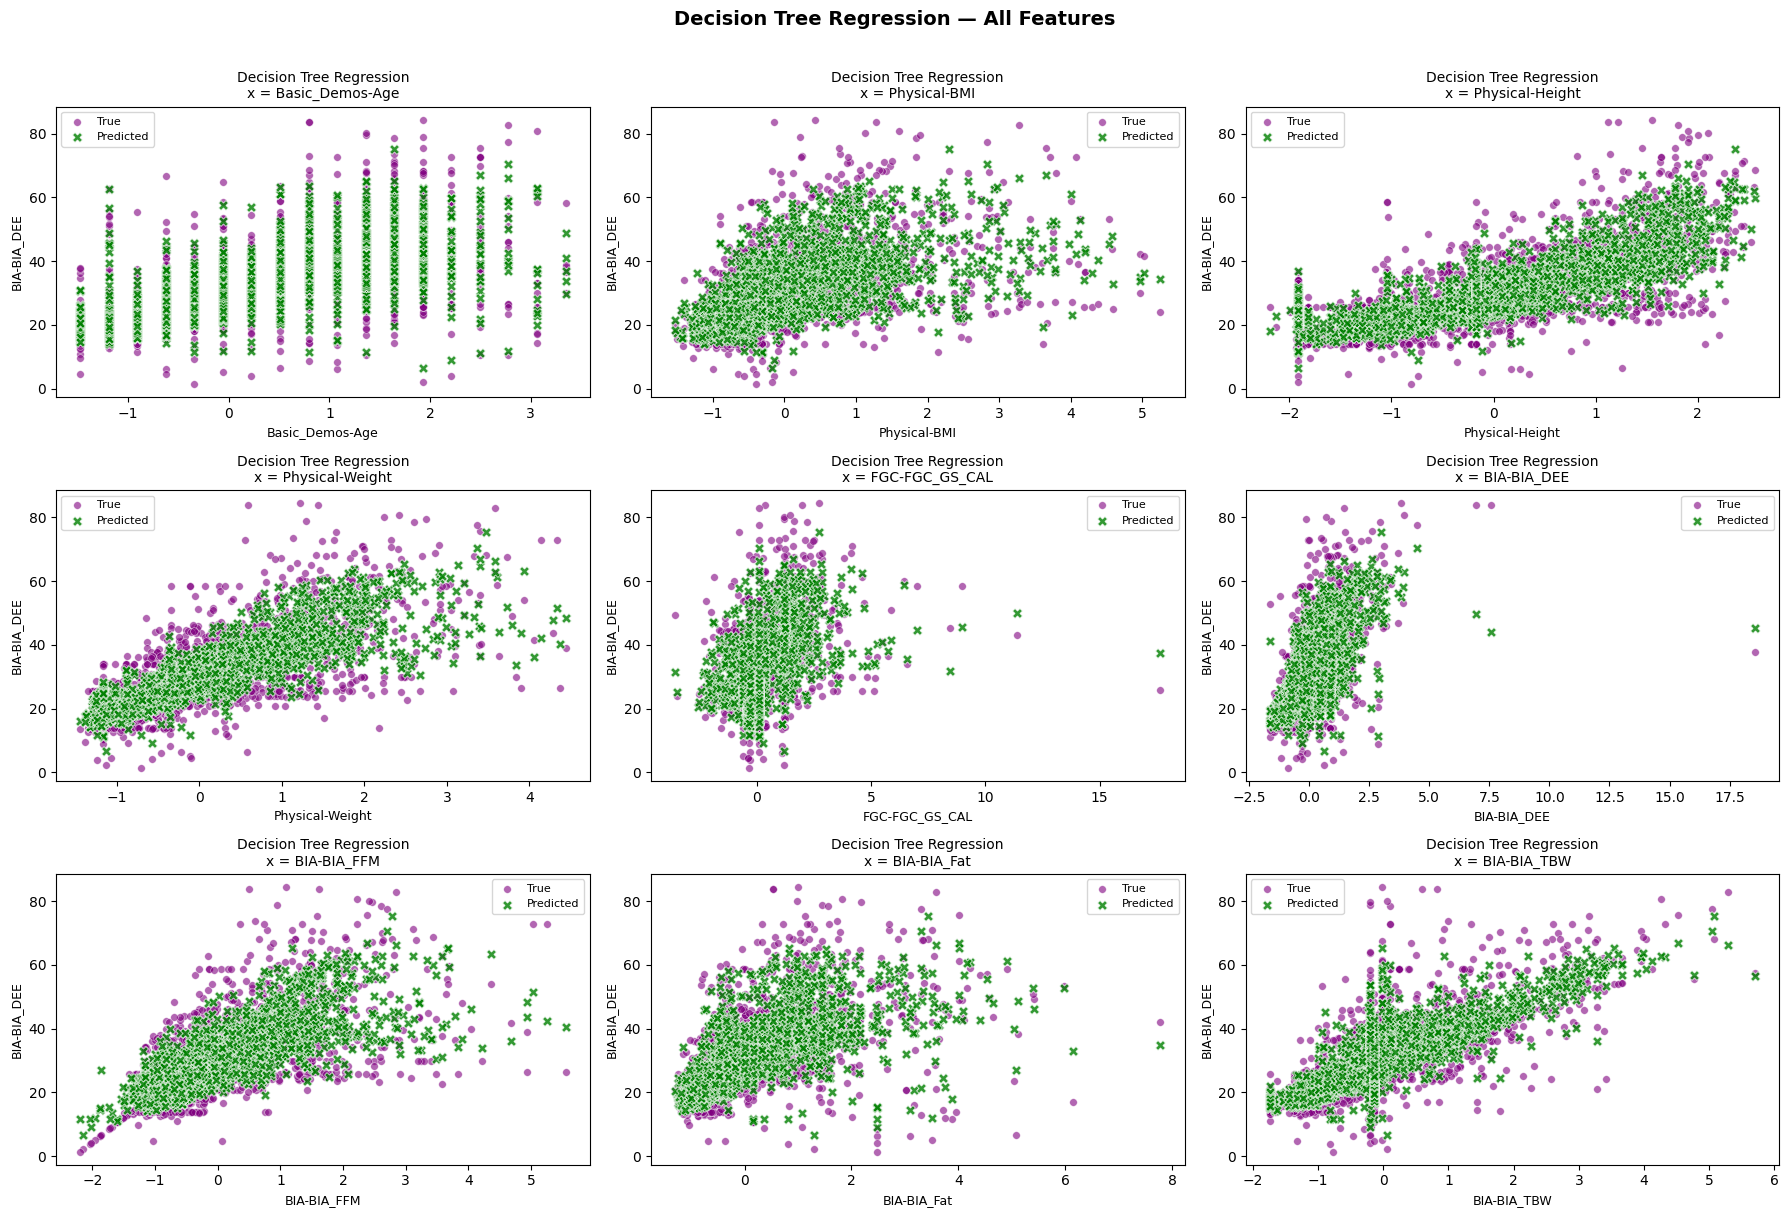

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_all_feature_predictions(X_test, y_test, model, feature_names=None,
                                  title='Model Predictions', color_true='purple',
                                  color_pred='green'):
    """
    Plots predicted vs true values for every feature in X_test as the x-axis.

    Parameters
    ----------
    X_test        : test features array  shape (n_samples, n_features)
    y_test        : true target values   shape (n_samples,)
    model         : trained model with .predict() method
    feature_names : list of feature names — if None uses ['feature_0', ...]
    title         : base title for each subplot
    color_true    : color for true values
    color_pred    : color for predicted values
    """

    n_features = X_test.shape[1]
    y_pred     = model.predict(X_test)

    # ── Feature names ─────────────────────────────────────────────────────────
    if feature_names is None:
        feature_names = [f'feature_{i}' for i in range(n_features)]

    # ── Grid layout — auto calculate rows and cols ────────────────────────────
    n_cols = 3                                    # 3 plots per row
    n_rows = math.ceil(n_features / n_cols)       # enough rows to fit all

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 6, n_rows * 4))
    axes = axes.flatten()     # convert 2D grid to 1D list for easy iteration

    # ── One plot per feature ──────────────────────────────────────────────────
    for i in range(n_features):
        ax = axes[i]

        plot_df = pd.DataFrame({
            'feature':   X_test[:, i],    # ← X_test[:, i] changes each loop
            'true':      y_test,
            'predicted': y_pred,
        })

        # true values
        sns.scatterplot(data=plot_df, x='feature', y='true',
                        label='True', color=color_true,
                        alpha=0.6, s=30, ax=ax)

        # predicted values
        sns.scatterplot(data=plot_df, x='feature', y='predicted',
                        label='Predicted', marker='X', color=color_pred,
                        alpha=0.8, s=50, ax=ax)

        ax.set_title(f'{title}\nx = {feature_names[i]}', fontsize=10)
        ax.set_xlabel(feature_names[i], fontsize=9)
        ax.set_ylabel('BIA-BIA_SMM', fontsize=9)
        ax.legend(fontsize=8)

    # ── Hide empty subplots if n_features is not divisible by n_cols ─────────
    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'{title} — All Features', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
feature_names = ['Basic_Demos-Age',
 'Physical-BMI',
 'Physical-Height',
 'Physical-Weight',
 'FGC-FGC_GS_CAL',
 'BIA-BIA_DEE',
 'BIA-BIA_FFM',
 'BIA-BIA_Fat',
 'BIA-BIA_TBW']   # ← replace with your actual column names, or leave None for auto naming

plot_all_feature_predictions(
    X_test        = X_test,
    y_test        = y_test,
    model         = best_model,
    feature_names = feature_names,
    title         = 'Decision Tree Regression',
    color_true    = 'purple',
    color_pred    = 'green',
)

# RF BIA-BIA_DEE

## Random forest (all features)

In [76]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [77]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'BIA-BIA_DEE']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['BIA-BIA_DEE'])


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 17)
y shape : (8396,)
Classes : [ 1073.45        1077.06715412  1079.4        ... 10452.89397059
 11248.19619725 17311.2       ]
Class counts : {1073.45: 19, 1077.0671541161732: 1, 1079.4: 1, 1080.5581911298004: 1, 1100.0028676222869: 1, 1106.1469184806892: 1, 1107.0154416262235: 1, 1108.078960213512: 1, 1111.29: 1, 1114.0573859780768: 1, 1120.0215031116054: 1, 1123.5028575929523: 1, 1123.68: 1, 1124.63: 1, 1126.3466711154938: 1, 1126.9035780971435: 1, 1129.51: 1, 1131.8455425729587: 1, 1134.2311571512626: 1, 1134.6407820585612: 1, 1135.8979512914534: 1, 1135.9745508801589: 1, 1136.5106404174062: 1, 1137.7702302833686: 1, 1139.228581020305: 1, 1140.370097784295: 1, 1140.5231893780142: 1, 1142.1: 1, 1143.82: 3, 1147.8713169173056: 1, 1148.7061125753971: 1, 1150.134339878573: 1, 1154.2248870158826: 1, 1154.47: 1, 1154.86: 1, 1158.5181756207703: 1, 1159.4774994023544: 1, 1159.67: 1, 1160.268831248877: 1, 1160.271305673793: 1, 1161.4917350758665: 1, 1162.13: 1, 1163.18: 1,

In [78]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [79]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {1073.45: 10, 1077.0671541161732: 1, 1079.4: 1, 1080.5581911298004: 1, 1100.0028676222869: 1, 1106.1469184806892: 1, 1107.0154416262235: 1, 1108.078960213512: 1, 1111.29: 1, 1114.0573859780768: 1, 1123.68: 1, 1124.63: 1, 1126.3466711154938: 1, 1126.9035780971435: 1, 1131.8455425729587: 1, 1134.2311571512626: 1, 1134.6407820585612: 1, 1135.9745508801589: 1, 1137.7702302833686: 1, 1139.228581020305: 1, 1143.82: 2, 1147.8713169173056: 1, 1148.7061125753971: 1, 1150.134339878573: 1, 1154.2248870158826: 1, 1154.47: 1, 1158.5181756207703: 1, 1159.67: 1, 1160.268831248877: 1, 1160.271305673793: 1, 1162.13: 1, 1163.18: 1, 1163.4314152508211: 1, 1168.535454558638: 1, 1172.759190306646: 1, 1175.05: 1, 1176.67: 1, 1177.16: 1, 1177.97: 1, 1183.3: 1, 1183.3575287650178: 1, 1184.902269206632: 1, 1186.11: 1, 1188.23: 1, 1189.2204634362183: 1, 1191.8982753220002: 1, 1191.9644392925816: 1, 1193.4533437980467: 1, 1194.93: 1, 1196.0199679381444: 1, 1198.75: 1, 1198.8600698233115: 1, 1198.9

In [80]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [81]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [82]:
def plot_roc_curve(X_test, y_test, best_model):    
# Predizioni probabilistiche
    y_score = best_model.predict_proba(X_test)

    # Classi
    classes = np.unique(y_test)

    # Binarizzazione delle etichette
    y_test_bin = label_binarize(y_test, classes=classes)

    # Plot
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Classe {class_name} (AUC = {roc_auc:.3f})'
        )

    # Linea casuale
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

In [83]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         [ 'friedman_mse', 'absolute_error', 'squared_error'],
}

In [84]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=KFold(                     
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='r2',  
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['friedman_mse', 'absolute_error', ...], 'max_depth': [5, 7, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that c

In [85]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")


── Best hyperparameters found ──────────────────────────
  n_estimators        : 200
  min_samples_split   : 10
  min_samples_leaf    : 2
  max_features        : sqrt
  max_depth           : 15
  criterion           : squared_error

  F1-macro (CV): 0.5878


In [86]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest params : {random_search.best_params_}")
print(f"RMSE  (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE   (test): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²    (test): {r2_score(y_test, y_pred):.4f}")


Best params : {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'criterion': 'squared_error'}
RMSE  (test): 294.0116
MAE   (test): 153.5447
R²    (test): 0.6106


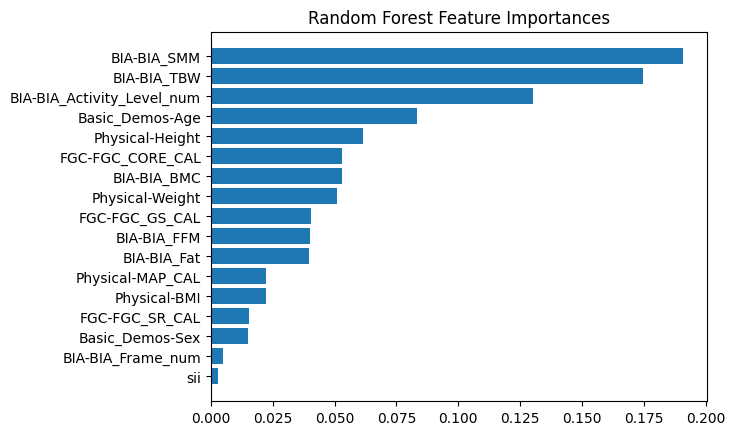

In [87]:
feature_imp(best_model, attributes)

## Random forest (reduced features)

In [88]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [89]:
column2drop = ['id', 'sii', 'Basic_Demos-Sex', 'Physical-MAP_CAL', 'FGC-FGC_CORE_CAL', 'FGC-FGC_SR_CAL', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_Frame_num']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'BIA-BIA_DEE']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['BIA-BIA_DEE'])


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 9)
y shape : (8396,)
Classes : [ 1073.45        1077.06715412  1079.4        ... 10452.89397059
 11248.19619725 17311.2       ]
Class counts : {1073.45: 19, 1077.0671541161732: 1, 1079.4: 1, 1080.5581911298004: 1, 1100.0028676222869: 1, 1106.1469184806892: 1, 1107.0154416262235: 1, 1108.078960213512: 1, 1111.29: 1, 1114.0573859780768: 1, 1120.0215031116054: 1, 1123.5028575929523: 1, 1123.68: 1, 1124.63: 1, 1126.3466711154938: 1, 1126.9035780971435: 1, 1129.51: 1, 1131.8455425729587: 1, 1134.2311571512626: 1, 1134.6407820585612: 1, 1135.8979512914534: 1, 1135.9745508801589: 1, 1136.5106404174062: 1, 1137.7702302833686: 1, 1139.228581020305: 1, 1140.370097784295: 1, 1140.5231893780142: 1, 1142.1: 1, 1143.82: 3, 1147.8713169173056: 1, 1148.7061125753971: 1, 1150.134339878573: 1, 1154.2248870158826: 1, 1154.47: 1, 1154.86: 1, 1158.5181756207703: 1, 1159.4774994023544: 1, 1159.67: 1, 1160.268831248877: 1, 1160.271305673793: 1, 1161.4917350758665: 1, 1162.13: 1, 1163.18: 1, 

In [90]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [91]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {1073.45: 10, 1077.0671541161732: 1, 1079.4: 1, 1080.5581911298004: 1, 1100.0028676222869: 1, 1106.1469184806892: 1, 1107.0154416262235: 1, 1108.078960213512: 1, 1111.29: 1, 1114.0573859780768: 1, 1123.68: 1, 1124.63: 1, 1126.3466711154938: 1, 1126.9035780971435: 1, 1131.8455425729587: 1, 1134.2311571512626: 1, 1134.6407820585612: 1, 1135.9745508801589: 1, 1137.7702302833686: 1, 1139.228581020305: 1, 1143.82: 2, 1147.8713169173056: 1, 1148.7061125753971: 1, 1150.134339878573: 1, 1154.2248870158826: 1, 1154.47: 1, 1158.5181756207703: 1, 1159.67: 1, 1160.268831248877: 1, 1160.271305673793: 1, 1162.13: 1, 1163.18: 1, 1163.4314152508211: 1, 1168.535454558638: 1, 1172.759190306646: 1, 1175.05: 1, 1176.67: 1, 1177.16: 1, 1177.97: 1, 1183.3: 1, 1183.3575287650178: 1, 1184.902269206632: 1, 1186.11: 1, 1188.23: 1, 1189.2204634362183: 1, 1191.8982753220002: 1, 1191.9644392925816: 1, 1193.4533437980467: 1, 1194.93: 1, 1196.0199679381444: 1, 1198.75: 1, 1198.8600698233115: 1, 1198.9

In [92]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [93]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [94]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         [ 'friedman_mse', 'absolute_error', 'squared_error'],
}

In [95]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=KFold(                     
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='r2',  
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['friedman_mse', 'absolute_error', ...], 'max_depth': [5, 7, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that c

In [96]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")


── Best hyperparameters found ──────────────────────────
  n_estimators        : 300
  min_samples_split   : 5
  min_samples_leaf    : 2
  max_features        : sqrt
  max_depth           : 10
  criterion           : friedman_mse

  F1-macro (CV): 0.4493


In [97]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest params : {random_search.best_params_}")
print(f"RMSE  (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE   (test): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²    (test): {r2_score(y_test, y_pred):.4f}")


Best params : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'friedman_mse'}
RMSE  (test): 342.7801
MAE   (test): 213.2663
R²    (test): 0.4707


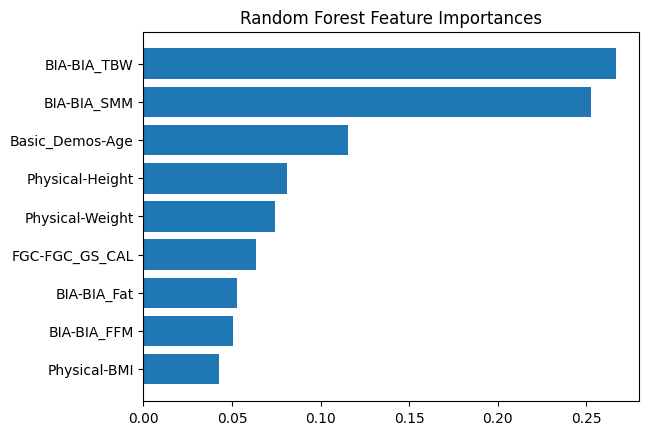

In [98]:
feature_imp(best_model, attributes)

## GRAPHIC 

In [ ]:
attributes

['Basic_Demos-Age',
 'Basic_Demos-Sex',
 'Physical-BMI',
 'Physical-Height',
 'Physical-Weight',
 'Physical-MAP_CAL',
 'FGC-FGC_CORE_CAL',
 'FGC-FGC_GS_CAL',
 'FGC-FGC_SR_CAL',
 'BIA-BIA_Activity_Level_num',
 'BIA-BIA_BMC',
 'BIA-BIA_DEE',
 'BIA-BIA_FFM',
 'BIA-BIA_Fat',
 'BIA-BIA_Frame_num',
 'BIA-BIA_TBW',
 'sii']

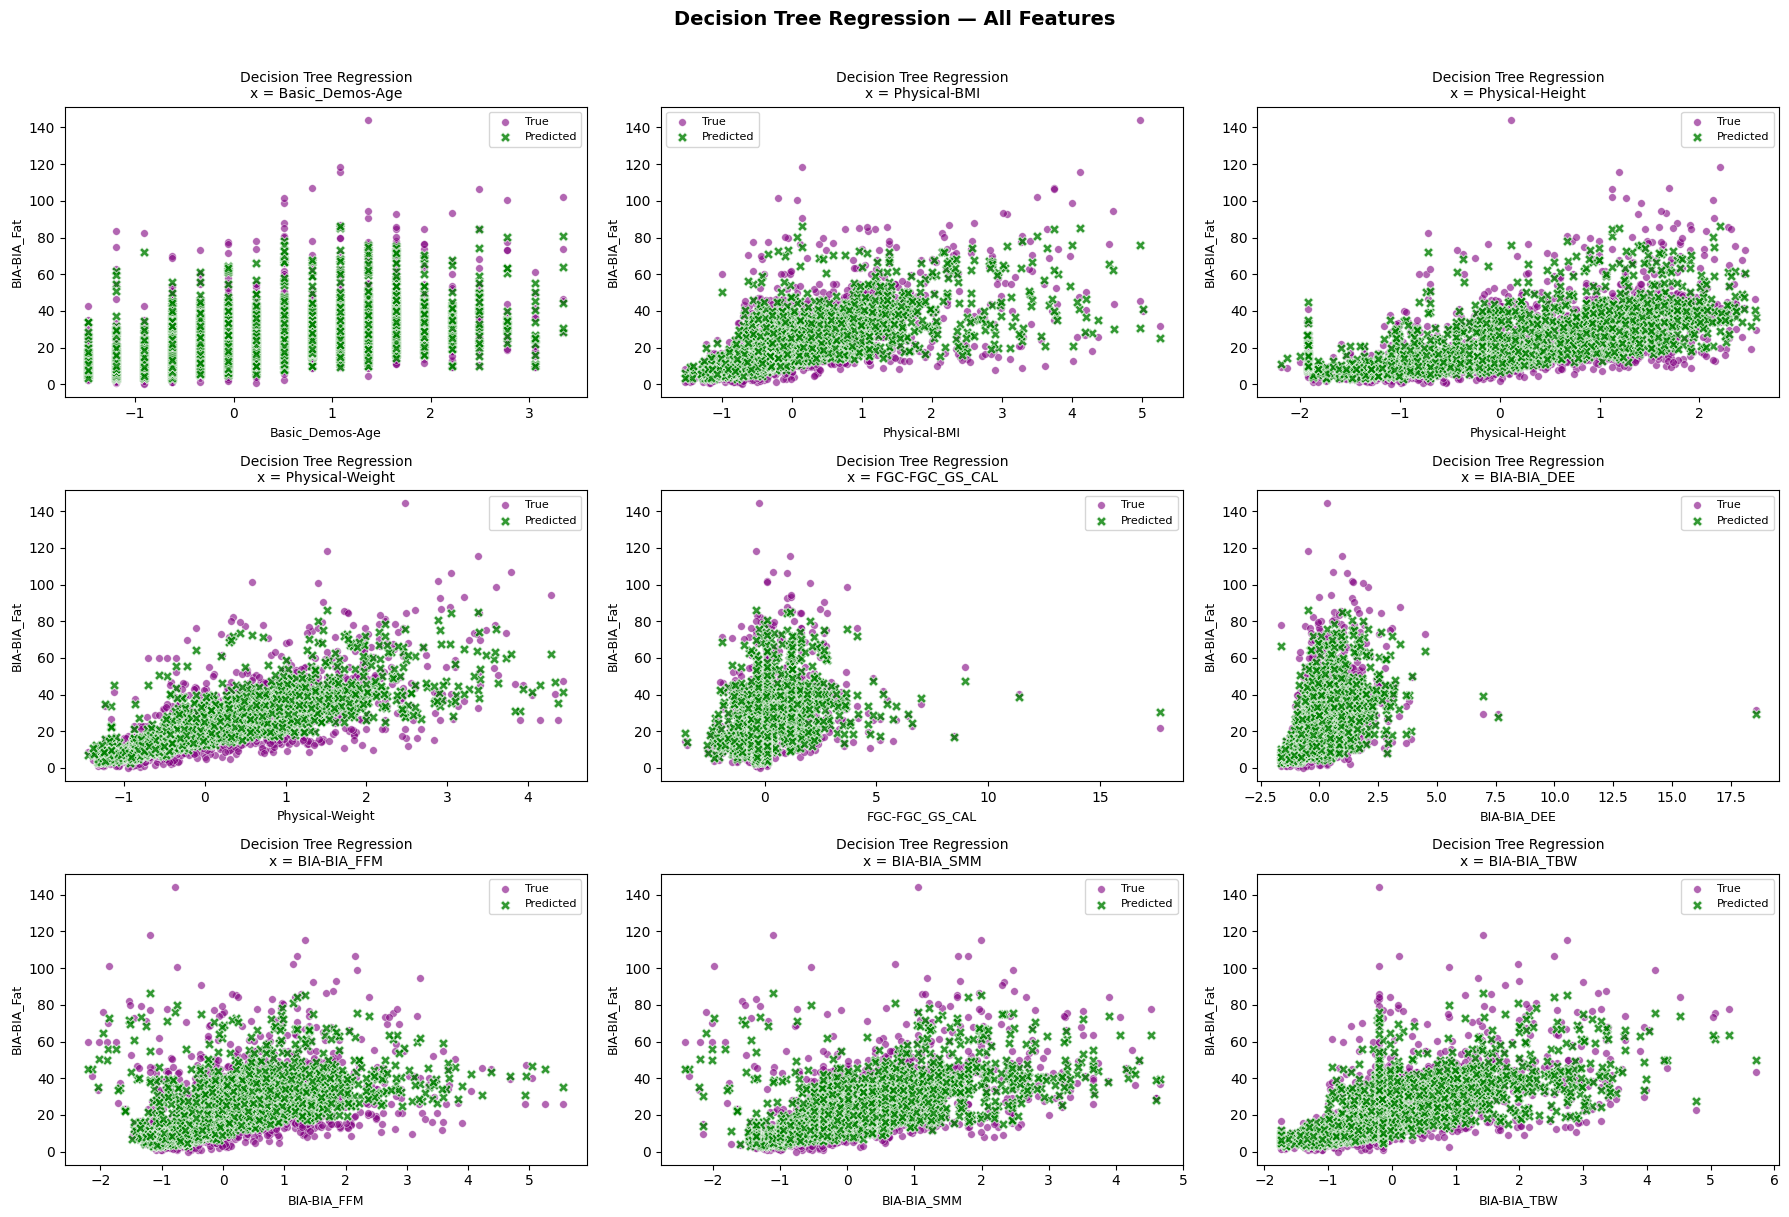

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_all_feature_predictions(X_test, y_test, model, feature_names=None,
                                  title='Model Predictions', color_true='purple',
                                  color_pred='green'):
    """
    Plots predicted vs true values for every feature in X_test as the x-axis.

    Parameters
    ----------
    X_test        : test features array  shape (n_samples, n_features)
    y_test        : true target values   shape (n_samples,)
    model         : trained model with .predict() method
    feature_names : list of feature names — if None uses ['feature_0', ...]
    title         : base title for each subplot
    color_true    : color for true values
    color_pred    : color for predicted values
    """

    n_features = X_test.shape[1]
    y_pred     = model.predict(X_test)

    # ── Feature names ─────────────────────────────────────────────────────────
    if feature_names is None:
        feature_names = [f'feature_{i}' for i in range(n_features)]

    # ── Grid layout — auto calculate rows and cols ────────────────────────────
    n_cols = 3                                    # 3 plots per row
    n_rows = math.ceil(n_features / n_cols)       # enough rows to fit all

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 6, n_rows * 4))
    axes = axes.flatten()     # convert 2D grid to 1D list for easy iteration

    # ── One plot per feature ──────────────────────────────────────────────────
    for i in range(n_features):
        ax = axes[i]

        plot_df = pd.DataFrame({
            'feature':   X_test[:, i],    # ← X_test[:, i] changes each loop
            'true':      y_test,
            'predicted': y_pred,
        })

        # true values
        sns.scatterplot(data=plot_df, x='feature', y='true',
                        label='True', color=color_true,
                        alpha=0.6, s=30, ax=ax)

        # predicted values
        sns.scatterplot(data=plot_df, x='feature', y='predicted',
                        label='Predicted', marker='X', color=color_pred,
                        alpha=0.8, s=50, ax=ax)

        ax.set_title(f'{title}\nx = {feature_names[i]}', fontsize=10)
        ax.set_xlabel(feature_names[i], fontsize=9)
        ax.set_ylabel('BIA-BIA_DEE', fontsize=9)
        ax.legend(fontsize=8)

    # ── Hide empty subplots if n_features is not divisible by n_cols ─────────
    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'{title} — All Features', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
feature_names = [
'Basic_Demos-Age',
'Physical-BMI',
'Physical-Height',
'Physical-Weight',
'FGC-FGC_GS_CAL',
'BIA-BIA_FFM',
'BIA-BIA_SMM',
'BIA-BIA_TBW'
]   # ← replace with your actual column names, or leave None for auto naming

plot_all_feature_predictions(
    X_test        = X_test,
    y_test        = y_test,
    model         = best_model,
    feature_names = feature_names,
    title         = 'Decision Tree Regression',
    color_true    = 'purple',
    color_pred    = 'green',
)